# Dataset Class and Augmentation Strategy

The `MammogramDataset` class bridges the split CSVs and the cached .npy arrays into PyTorch-compatible interface. Augmentation is handled by Albumentations pipelines.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.dataset import MammogramDataset
from src.data.augment import train_augment, val_augment

TRAIN_CSV = Path("../data/cbis-ddsm/training/train.csv")
IMAGE_ROOT = Path("../data/cbis-ddsm/cbis_ddsm")

## Dataset Without Augmentation

Tensor shape: torch.Size([1, 224, 224])
Tensor dtype: torch.float32
Value range : [0.008, 1.000]
Label: 0.0


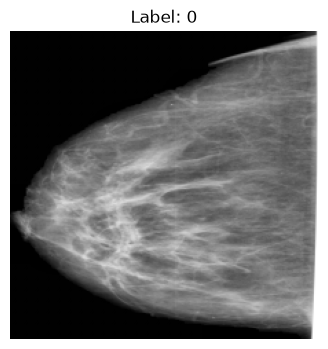

In [2]:
ds_raw = MammogramDataset(TRAIN_CSV, IMAGE_ROOT)
tensor, label = ds_raw[0]

print(f"Tensor shape: {tensor.shape}")
print(f"Tensor dtype: {tensor.dtype}")
print(f"Value range : [{tensor.min():.3f}, {tensor.max():.3f}]")
print(f"Label: {label.item()}")

plt.figure(figsize=(4, 4))
plt.imshow(tensor.squeeze(), cmap="gray")
plt.title(f"Label: {label.item():.0f}")
plt.axis("off")
plt.show()

## Validation Augmentation

Validation uses only resizing and normalisation, no random transformations. This ensures that validation metrics reflect model performance on unaltered data.

Tensor shape: torch.Size([1, 224, 224])
Tensor dtype: torch.float32
Value range : [-2.084, 2.249]
Label: 0.0


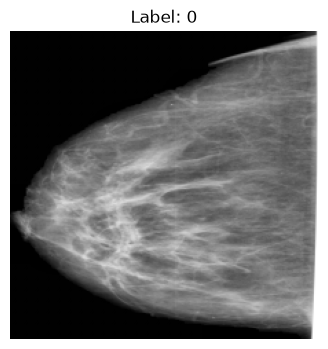

In [3]:
ds_val = MammogramDataset(TRAIN_CSV, IMAGE_ROOT, transform=val_augment(224))
tensor, label = ds_val[0]

print(f"Tensor shape: {tensor.shape}")
print(f"Tensor dtype: {tensor.dtype}")
print(f"Value range : [{tensor.min():.3f}, {tensor.max():.3f}]")
print(f"Label: {label.item()}")

plt.figure(figsize=(4, 4))
plt.imshow(tensor.squeeze(), cmap="gray")
plt.title(f"Label: {label.item():.0f}")
plt.axis("off")
plt.show()

## Training Augmentation

Training adds controlled randomness to improve model generalisation. The augmentation pipeline includes:

| Transform                | Parameters          | Rationale                          |
|--------------------------|---------------------|------------------------------------|
| HorizontalFlip           | p=0.5               | Left/right symmetry is valid       |
| Rotate                   | ±10°, p=0.5         | Slight tilt from positioning       |
| RandomBrightnessContrast | ±0.1, p=0.3         | Scanner variation                  |
| Resize                   | 224×224             | Fixed input size                   |
| Normalize                | ImageNet μ/σ        | Backbone compatibility             |

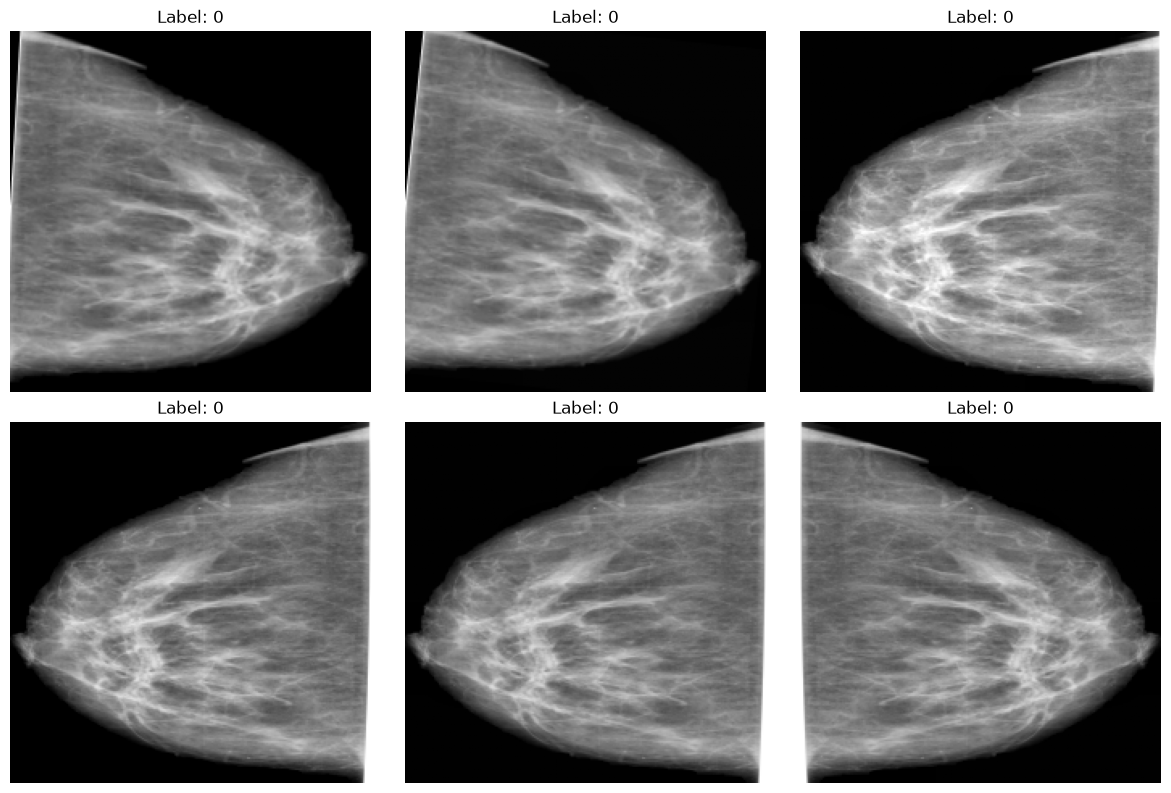

In [4]:
ds_train = MammogramDataset(TRAIN_CSV, IMAGE_ROOT, transform=train_augment(224))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax in axes.flat:
    tensor, label = ds_train[0]
    ax.imshow(tensor.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label.item():.0f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# DataLoader Integration

In [5]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
batch_x, batch_y = next(iter(loader))

print(f"Batch images shape: {batch_x.shape}")
print(f"Batch labels shape: {batch_y.shape}")

Batch images shape: torch.Size([4, 1, 224, 224])
Batch labels shape: torch.Size([4, 1])
